In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is 9EA6-79CD

 Directory of c:\Users\Radovan\OneDrive\Radboud\Studentships\Linda Drijvers\project\analysis

18/11/2025  10:24    <DIR>          .
29/10/2025  13:48    <DIR>          ..
18/11/2025  10:31            90.206 flicker_frow_ana.ipynb
               1 File(s)         90.206 bytes
               2 Dir(s)  106.489.446.400 bytes free


In [5]:
fpath = r"C:\Users\Radovan\Downloads\sub-P005_ses-S003_task-Default_run-001_eeg.xdf"

In [6]:
fpath

'C:\\Users\\Radovan\\Downloads\\sub-P005_ses-S003_task-Default_run-001_eeg.xdf'

In [7]:
import pyxdf

In [8]:
stream, _ids = pyxdf.load_xdf(fpath)

In [ ]:
timestamps = stream[0]['time_stamps']

# timeseries: 1D array of sample times (s)
# timestamps: 1D array of optosensor values (same length as timeseries)

t_samples = np.asarray(timestamps).ravel()   # time per sample (s)
sig       = np.asarray(timeseries).ravel()   # raw optosensor signal

# 1) Binarize signal (if it's already 0/1 this just casts it)
#sig_bin = (sig != 0).astype(int)

# 2) Detect 0 -> 1 transitions (rising edges)
transitions = np.diff(sig_bin)
edge_idx = np.where(transitions == 1)[0] + 1   # +1 because diff shifts by 1

# 3) True event times: one per luminance change
event_times = t_samples[edge_idx]              # in seconds


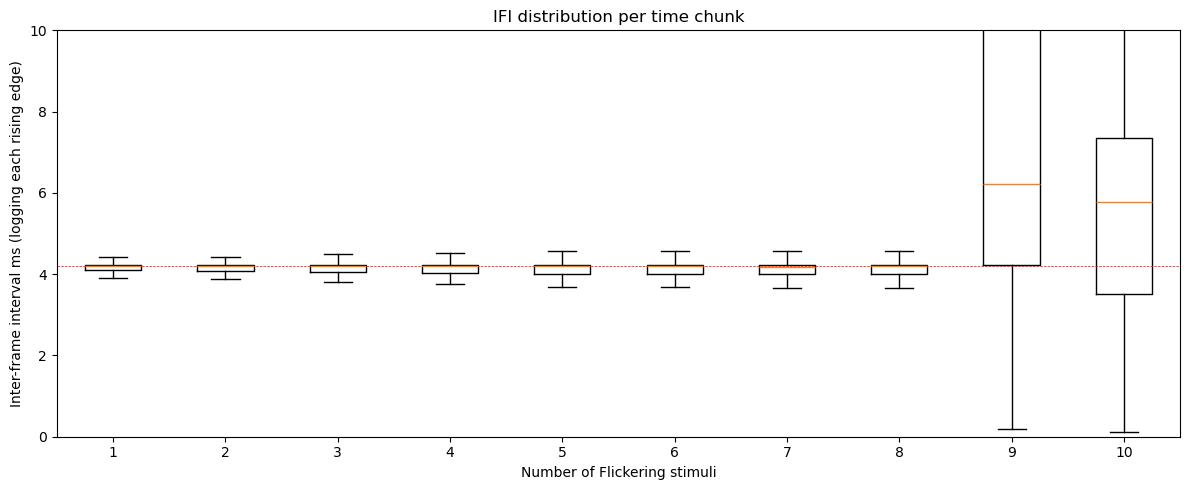

In [172]:
# 1) Inter-frame intervals (seconds) and their associated times
ifi = np.diff(event_times)                # IFI in seconds
ifi_ms = ifi * 1000.0                    # IFI in ms
ifi_time = event_times[:-1] + 0.5 * ifi  # time (s) at center of each IFI
block_size = 10
# 2) Define 10 uniformly spaced time chunks over the IFI time range
t_start, t_end = ifi_time[0], ifi_time[-1]
edges = np.linspace(t_start, t_end, block_size+1)  # 11 edges → 10 chunks

blocks_ms = []   # list of arrays, IFIs (ms) per chunk
labels = []

for i in range(block_size):
    t0, t1 = edges[i], edges[i+1]

    # last chunk includes the endpoint
    if i < block_size-1:
        mask = (ifi_time >= t0) & (ifi_time < t1)
    else:
        mask = (ifi_time >= t0) & (ifi_time <= t1)

    ifi_block = ifi_ms[mask]

    if ifi_block.size == 0:
        # empty chunk → put NaN to keep 10 box positions
        blocks_ms.append(np.array([np.nan]))
    else:
        blocks_ms.append(ifi_block)

    labels.append(str(i+1))

# 3) Boxplot: IFI distribution per chunk
plt.figure(figsize=(12,5))
plt.boxplot(blocks_ms, positions=np.arange(1, block_size+1), showfliers=False)
plt.xlabel("Number of Flickering stimuli")
plt.ylabel("Inter-frame interval ms (logging each rising edge)")
plt.title("IFI distribution per time chunk")
plt.xticks(np.arange(1, block_size+1), labels)
plt.ylim(0,10)
plt.axhline(4.2, color = 'red', linestyle = '--', linewidth = 0.5)
plt.tight_layout()
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x1fe840acfd0>,
 'caps': [<matplotlib.lines.Line2D at 0x1fe840ad510>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fe840acd30>],
 'medians': [<matplotlib.lines.Line2D at 0x1fe840ada50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fe840adcf0>],
 'means': []}

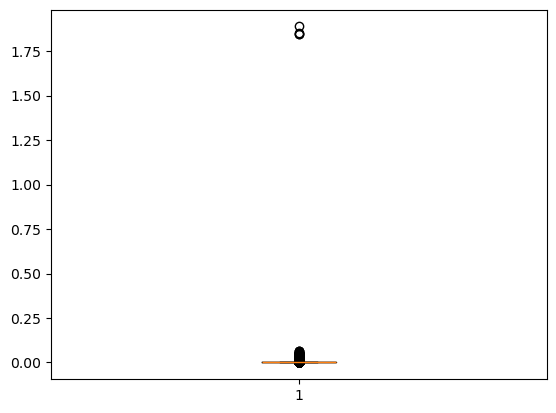

In [143]:
plt.boxplot(np.diff(event_times))

In [135]:
ifi = np.diff(event_times)        # seconds between luminance changes
ifi_ms = ifi * 1000.0

print("Min IFI (ms):", ifi_ms.min())
print("1st percentile (ms):", np.percentile(ifi_ms, 1))
print("Median IFI (ms):", np.median(ifi_ms))


Min IFI (ms): 0.02519999907235615
1st percentile (ms): 0.6730000004608883
Median IFI (ms): 4.2043999947054544


In [10]:
timeseries = stream[0]['time_series'].flatten()


In [11]:
#estimate fs

ts = np.asarray(stream[0]["time_stamps"])
dt = np.diff(ts)            # seconds between samples
fs_est = 1.0 / np.median(dt)

print("Estimated fs:", fs_est, "Hz")

Estimated fs: 645.4111276743815 Hz


In [125]:
timeseries

array([0, 1, 0, ..., 0, 1, 0], dtype=int8)

ValueError: x and y must be the same size

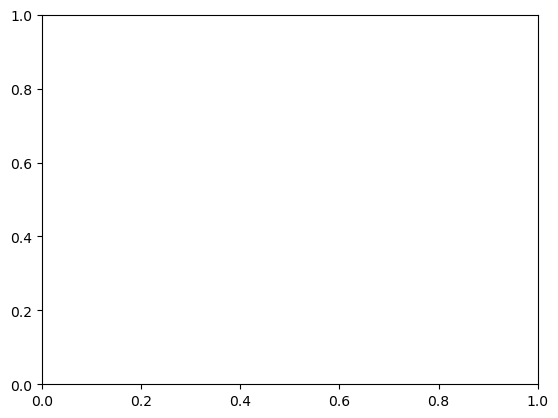

In [136]:
%matplotlib inline
plt.close()
plt.scatter(timestamps, timeseries)
plt.xlim(12050.15,12050.2)
plt.show()

In [137]:
ifi = np.diff(timestamps)         # seconds
ifi_ms = ifi * 1000

print("Min ifi_ms_filt_ms_filt_ms_filt_ms_filt (ms):", ifi_ms.min())
print("1st percentile (ms):", np.percentile(ifi_ms, 1))
print("Median IFI (ms):", np.median(ifi_ms))


Min ifi_ms_filt_ms_filt_ms_filt_ms_filt (ms): 0.00819999877421651
1st percentile (ms): 0.13550000039685983
Median IFI (ms): 1.5493999981117668


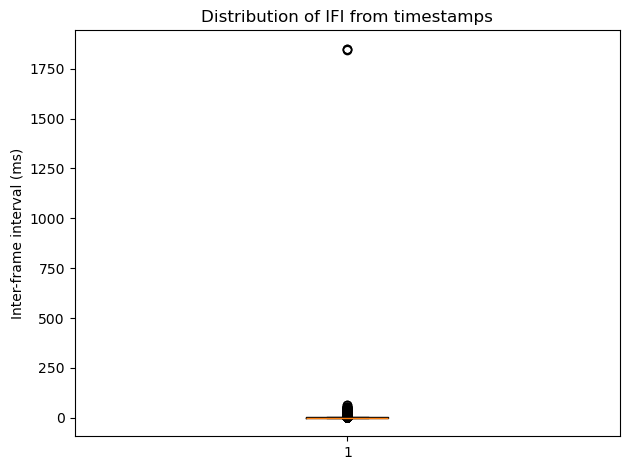

IFI statistics:
  N IFIs:           1277922
  Mean IFI:         2.223 ms  (~449.88 Hz)
  Median IFI:       1.547 ms  (~646.50 Hz)
  Std IFI:          3.472 ms
  Min IFI:          0.012 ms
  Max IFI:          1849.854 ms
  5th percentile:   0.206 ms
  95th percentile:  5.541 ms


In [51]:
ifi = np.diff(timestamps)
# 2) Boxplot (in ms)
ifi_ms = ifi * 1000.0

plt.figure()
plt.boxplot(ifi_ms)
plt.ylabel("Inter-frame interval (ms)")
plt.title("Distribution of IFI from timestamps")
plt.tight_layout()
plt.show()

# 3) Summary statistics
mean_ifi = np.mean(ifi)
median_ifi = np.median(ifi)
std_ifi = np.std(ifi)
min_ifi = np.min(ifi)
max_ifi = np.max(ifi)
p5 = np.percentile(ifi, 5)
p95 = np.percentile(ifi, 95)

# implied refresh rates (Hz)
mean_rate = 1.0 / mean_ifi
median_rate = 1.0 / median_ifi

print("IFI statistics:")
print(f"  N IFIs:           {ifi.size}")
print(f"  Mean IFI:         {mean_ifi*1000:.3f} ms  (~{mean_rate:.2f} Hz)")
print(f"  Median IFI:       {median_ifi*1000:.3f} ms  (~{median_rate:.2f} Hz)")
print(f"  Std IFI:          {std_ifi*1000:.3f} ms")
print(f"  Min IFI:          {min_ifi*1000:.3f} ms")
print(f"  Max IFI:          {max_ifi*1000:.3f} ms")
print(f"  5th percentile:   {p5*1000:.3f} ms")
print(f"  95th percentile:  {p95*1000:.3f} ms")

In [116]:
ifi_ms.shape

(1277922,)

In [117]:
ifi_ms_filt.shape

(599260,)

C:\Users\Radovan\AppData\Local\Temp\ipykernel_9116\2018384342.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


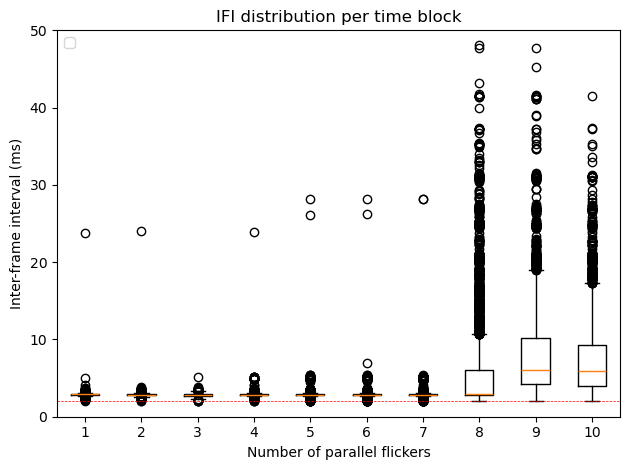

Target IFI for 480 Hz: 2.083333 ms

Per-block IFI statistics (ms):
Block  1: n=68167, mean=2.858, median=2.877, std=0.145, min=2.043, max=23.800, n>1/480s = 68166 (99.999%)
Block  2: n=68161, mean=2.853, median=2.873, std=0.164, min=2.062, max=24.057, n>1/480s = 68159 (99.997%)
Block  3: n=68161, mean=2.846, median=2.851, std=0.180, min=2.003, max=5.088, n>1/480s = 68157 (99.994%)
Block  4: n=68151, mean=2.865, median=2.856, std=0.180, min=2.006, max=23.857, n>1/480s = 68149 (99.997%)
Block  5: n=68112, mean=2.869, median=2.865, std=0.215, min=2.008, max=28.137, n>1/480s = 68098 (99.979%)
Block  6: n=68086, mean=2.853, median=2.854, std=0.210, min=2.008, max=28.136, n>1/480s = 68070 (99.977%)
Block  7: n=67069, mean=2.894, median=2.847, std=10.067, min=2.021, max=1848.003, n>1/480s = 67043 (99.961%)
Block  8: n=46898, mean=5.089, median=2.895, std=9.485, min=2.000, max=1849.854, n>1/480s = 46834 (99.864%)
Block  9: n=36489, mean=7.329, median=6.011, std=3.911, min=2.000, max=51.791, n>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# 1) Inter-frame intervals (seconds)
ifi = np.diff(timestamps)
ifi_time = timestamps[:-1] +  ifi   # midpoint time of each IFI

# 2) Define 10 equally spaced time blocks over the IFI time range
t_start, t_end = ifi_time[0], ifi_time[-1]
edges = np.linspace(t_start, t_end, 11)  # 11 edges → 10 blocks

blocks_ms = []   # IFIs per block (ms) for boxplot
labels = []
stats = []

# Threshold IFI for 480 Hz (in seconds and ms)
target_hz = 480.0
target_ifi = 1.0 / target_hz            # seconds
target_ifi_ms = target_ifi * 1000.0     # ms

for i in range(10):
    t0, t1 = edges[i], edges[i+1]

    # last block inclusive of the end
    if i < 9:
        mask = (ifi_time >= t0) & (ifi_time < t1)
    else:
        mask = (ifi_time >= t0) & (ifi_time <= t1)

    ifi_block = ifi[mask]

    if ifi_block.size == 0:
        blocks_ms.append(np.array([np.nan]))
        stats.append({
            "block": i+1,
            "n": 0,
            "mean_ms": np.nan,
            "median_ms": np.nan,
            "std_ms": np.nan,
            "min_ms": np.nan,
            "max_ms": np.nan,
            "n_above_480": 0,
            "pct_above_480": np.nan,
        })
    else:
        ifi_block_ms = ifi_block * 1000.0  # convert to ms
        blocks_ms.append(ifi_block_ms)

        n_block = int(ifi_block_ms.size)
        n_above = int(np.sum(ifi_block_ms > target_ifi_ms))
        pct_above = (n_above / n_block) * 100.0

        stats.append({
            "block": i+1,
            "n": n_block,
            "mean_ms": float(np.mean(ifi_block_ms)),
            "median_ms": float(np.median(ifi_block_ms)),
            "std_ms": float(np.std(ifi_block_ms)),
            "min_ms": float(np.min(ifi_block_ms)),
            "max_ms": float(np.max(ifi_block_ms)),
            "n_above_480": n_above,
            "pct_above_480": pct_above,
        })

    labels.append(str(i+1))

# 3) Boxplot
plt.figure()
plt.boxplot(blocks_ms, positions=np.arange(1, 11))
plt.xlabel("Number of parallel flickers")
plt.ylabel("Inter-frame interval (ms)")
plt.title("IFI distribution per time block")
plt.xticks(np.arange(1, 11), labels)
plt.ylim(0, 50)
plt.legend(loc='upper left')
plt.axhline(target_ifi_ms, linestyle="--", linewidth=0.5, color = 'red', label=f"1/480 Hz ({target_ifi:.3f} ms)")
plt.tight_layout()
plt.show()

# 4) Print summary statistics
print(f"Target IFI for 480 Hz: {target_ifi_ms:.6f} ms\n")
print("Per-block IFI statistics (ms):")
for s in stats:
    if s["n"] == 0:
        print(
            f"Block {s['block']:2d}: "
            f"n={s['n']:5d}, "
            f"mean=   nan, median=   nan, std=   nan, min=   nan, max=   nan, "
            f"n>1/480s = 0 (pct=nan)"
        )
    else:
        print(
            f"Block {s['block']:2d}: "
            f"n={s['n']:5d}, "
            f"mean={s['mean_ms']:.3f}, "
            f"median={s['median_ms']:.3f}, "
            f"std={s['std_ms']:.3f}, "
            f"min={s['min_ms']:.3f}, "
            f"max={s['max_ms']:.3f}, "
            f"n>1/480s = {s['n_above_480']:5d} "
            f"({s['pct_above_480']:.3f}%)"
        )


In [112]:
1000/ np.diff(timestamps*1000).min()

82644.64126911116

In [ ]:
1

In [92]:
(np.diff(timestamps) > target_ifi).sum()

598362

In [89]:
timestamps.shape

(1277923,)